# **LENDING CLUB ANALYSIS**

The analysis is divided into four parts:



1.  Data Understanding
2.  Data Cleaning
3.  Data Analysing
4.  Recommendations





In [ ]:
#importing the libraries for the project analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing the data of Lending Club
loan=pd.read_csv('loan_csv.csv')

/tmp/ipykernel_1867/100582909.py:2: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  loan=pd.read_csv('loan_csv.csv')


In [ ]:
loan.shape

(39717, 111)

In [ ]:
#Checking whether the data has been uploaded successfully
loan.head(1)

In [ ]:
#checking the size of the data
loan.shape

In [ ]:
#getting the summary of the data such as data type of each column and size of the data by info function
loan.info(verbose=True,show_counts=True)

# DATA UNDERSTANDING

In the step we would understanding the data such knowing the data types of columns,size of the data and null values.
By this step the data cleaning can be done effeciently.

In [ ]:
loan.head(10)

In [ ]:
loan.columns

# Important Columns:
In this dataset there some important columns such as loan_amount,term,interest rate,purpose for the loan,grade etc.
The strategy is that to compare the default rate and then find some columns which are important to know the defaulters behaviors.
The variable will be compared with the loan_status as it makes the important impact in lending money.

# DATA CLEANING


After the data understanding we move ahead to data cleaning.
Cleaning the missing values either by deleting them or computing them with mean.median or mode.

In [ ]:
#In data cleaning first step is to check the null values in data
loan.isnull().sum()

In [ ]:
#to know the null values more properly, taking the percentage of null values
round(loan.isnull().sum()/len(loan.index),2)*100

,0
id,0.0
member_id,0.0
loan_amnt,0.0
funded_amnt,0.0
funded_amnt_inv,0.0
...,...
tax_liens,0.0
tot_hi_cred_lim,100.0
total_bal_ex_mort,100.0
total_bc_limit,100.0


We can many columns have 100% of missing values so we will get rid of them.

In [ ]:
#storing all the 100% null values column in a variable
missing_columns=loan.columns[100*(loan.isnull().sum()/len(loan.index))>90]
print(missing_columns)

Index(['mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog',
       'annual_inc_joint', 'dti_joint', 'verification_status_joint',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
       'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
       'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd',
       'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl',
       'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
       'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
 

In [ ]:
#droping all the columns
loan= loan.drop(missing_columns,axis=1)

In [ ]:
loan.shape

(39717, 55)

As we can see more than 50 columns has been deleted and it would become easy to analysis

In [ ]:
#let's check the remaining values
loan.isnull().sum()/len(loan.index)*100

In [ ]:
#as we see the two columns with missing values is 33% and 64%
#hence it may be deleted

loan.loc[ :, ['desc','mths_since_last_delinq']].head(10)

,desc,mths_since_last_delinq
0,Borrower added on 12/22/11 > I need to upgrade...,NaN
1,Borrower added on 12/22/11 > I plan to use thi...,NaN
2,NaN,NaN
3,Borrower added on 12/21/11 > to pay for prop...,35.0
4,Borrower added on 12/21/11 > I plan on combi...,38.0
5,NaN,NaN
6,Borrower added on 12/18/11 > I am planning o...,NaN
7,Borrower added on 12/16/11 > Downpayment for a...,NaN
8,Borrower added on 12/21/11 > I own a small hom...,NaN
9,Borrower added on 12/16/11 > I'm trying to b...,NaN


As the desc column is the writing of dates and purpose that can't be used that much.
mths_since_last_deling column has large number values missing so can't be used
hence deleting these two columns.

In [ ]:
loan = loan.drop(['desc','mths_since_last_delinq'],axis =1)


In [ ]:
loan.shape

(39717, 53)

There are some columns with small percentage of missing values. We would ignore such column.

Now let's check whether some rows have the missing values.

In [ ]:
#missing values in rows
loan.isnull().sum(axis=1)

In [ ]:
#checking if more than 5 number of values are missing in the rows
len(loan[loan.isnull().sum(axis=1)>5].index)

Hence there are not more than 5 values missing in the rows we would ignore them

# Checking whether all the columns are in right format.

In [ ]:
loan.info()

As the interest column is given in a object so for better analysis we need to change it in a float.

In [ ]:
#changing the data type of interest rate
loan['int_rate']=pd.to_numeric(loan['int_rate'].str.replace('%',''))

#loan['int_rate'] = loan['int_rate'].str.rstrip('%').astype(float)
#loan['int_rate'] = loan['int_rate'].apply(lambda x: pd.to_numeric(x.split("%")[0]))

In [ ]:
#checking the data type of interest rate
loan['int_rate'].dtype

dtype('float64')

In [ ]:
#checking again all the data types of the column

loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  38642 non-null  object 
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [ ]:
#the emp_length refers to the column which shows the employs experience of years in the current company

loan['emp_length']

,emp_length
0,10+ years
1,< 1 year
2,10+ years
3,10+ years
4,1 year
...,...
39712,4 years
39713,3 years
39714,< 1 year
39715,< 1 year


In [ ]:
#first just exracting the year and '<' sign from the column
loan['emp_length']=loan['emp_length'].str.extract(r'(\d+)')

In [ ]:
#changing the data type of the employlength
loan['emp_length']=loan['emp_length'].fillna(0).astype(int)

In [ ]:
#checking the employ length
loan['emp_length']

,emp_length
0,10
1,1
2,10
3,10
4,1
...,...
39712,4
39713,3
39714,1
39715,1


In [ ]:
#Let's check how many count of borrowera are in each emp_length years from 0 to 10
loan['emp_length'].value_counts()

,count
emp_length,
10,8879
1,7823
2,4388
3,4095
4,3436
5,3282
6,2229
7,1773
8,1479


In [ ]:
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  39717 non-null  int64  
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

Now all the has been cleared out.
The data types of the required columns has been changed.
Now we can move ahead with data analysis part.

# **DATA ANALYSIS **

Now let's move to the data analysis part.

Our main strategy is to know the column which are very important to analysis the defaulters for the comapny.In this, we will find which column shows a strong relationship with the laon status column.

# Here we would analysing with the help of visuales from seaborn.

In [ ]:
#analysing the columns
loan.columns

In [ ]:
#locating all the behavioral column in a variable for easy removal
behavior_var=['delinq_2yrs',
              'earliest_cr_line',
              'inq_last_6mths',
              'open_acc',
              'pub_rec',
              'revol_bal',
              'revol_util',
              'total_acc',
              'out_prncp',
              'out_prncp_inv',
              'total_pymnt',
              'total_pymnt_inv',
              'total_rec_prncp',
              'total_rec_late_fee',
              'total_rec_int',
              'recoveries',
              'collection_recovery_fee',
              'last_pymnt_d',
              'last_pymnt_amnt',
              'last_credit_pull_d',
              'application_type']

In [ ]:
df= loan.drop(behavior_var,axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  39717 non-null  int64  
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

In [ ]:
#we have no use state address,url and zip code so dropping that for better analysis
#title is same as the purpose so no use of that hence dropping this column too

df = df.drop(['title','url','zip_code','addr_state'],axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          39717 non-null  int64  
 1   member_id                   39717 non-null  int64  
 2   loan_amnt                   39717 non-null  int64  
 3   funded_amnt                 39717 non-null  int64  
 4   funded_amnt_inv             39717 non-null  float64
 5   term                        39717 non-null  object 
 6   int_rate                    39717 non-null  float64
 7   installment                 39717 non-null  float64
 8   grade                       39717 non-null  object 
 9   sub_grade                   39717 non-null  object 
 10  emp_title                   37258 non-null  object 
 11  emp_length                  39717 non-null  int64  
 12  home_ownership              39717 non-null  object 
 13  annual_inc                  397

Now let's take our targeted variable that is 'loan status'.
In this we would convert into binary such 0 and 1 for the analysis.
1= default person
0= **others**

In [ ]:
#knowing the ids in each status
df['loan_status'].value_counts()
#here we can that maximum number is fully paid

,count
loan_status,
Fully Paid,32950
Charged Off,5627
Current,1140


As we can see the fully paid are 32950 which is approx 82% of the total record and remaining percentage is of charged off and current.

In [ ]:
#here I have used this code we do not needed the current loan individuals hence created a mask that only counts fully paid and charged off and also as 0 and 1.
df['loan_status']=df['loan_status'].map({'Fully Paid':0,'Charged Off':1})

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0.0,32950
1.0,5627


# Univariate Analysis

Univariate analysis is a analysis where only one variable is has been analysed.

So let's move forward with univariate analysis.

In [ ]:
#default rate
round(np.mean(df['loan_status']),5)*100

np.float64(14.585999999999999)

So we can see the overall the percentage is 16%

now we have analysis what is 16% causing us

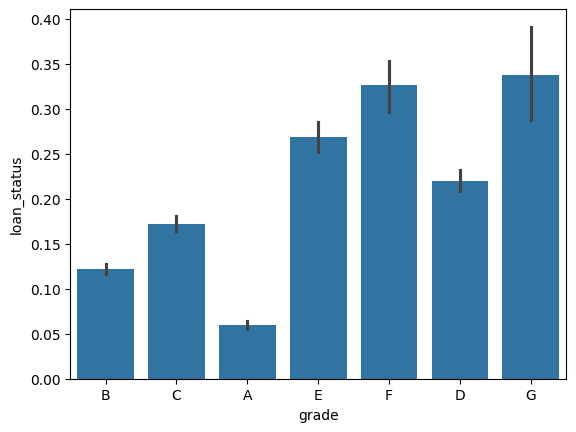

In [ ]:
#plotting default vales with grade
sns.barplot(x='grade',y='loan_status',data=df)
plt.show()

In [ ]:
def plot_cat(cat_var):
  sns.barplot(x=cat_var,y='loan_status',data=df)

  plt.show()

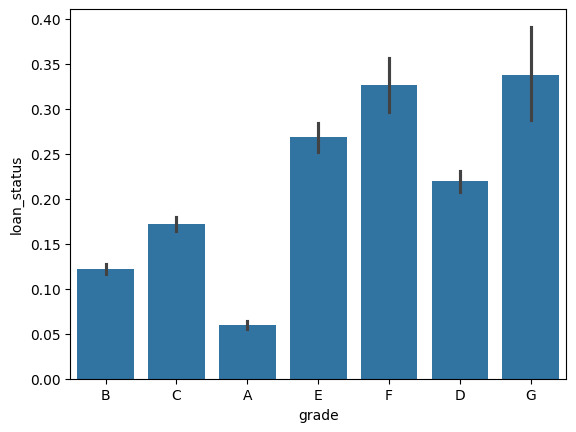

In [ ]:
#plotting with grade
plot_cat('grade')

*Grade Chart*

As we can the default grade is increasing from A to G as g is risky grade to provide loan.

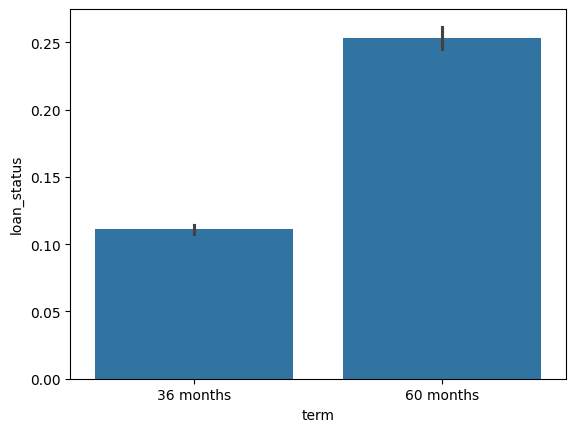

In [ ]:
plot_cat('term')

*Term* *Chart*

Here the term is of 36 months and 60 months.
The default rate of 60 months is very high compared to 36 months.

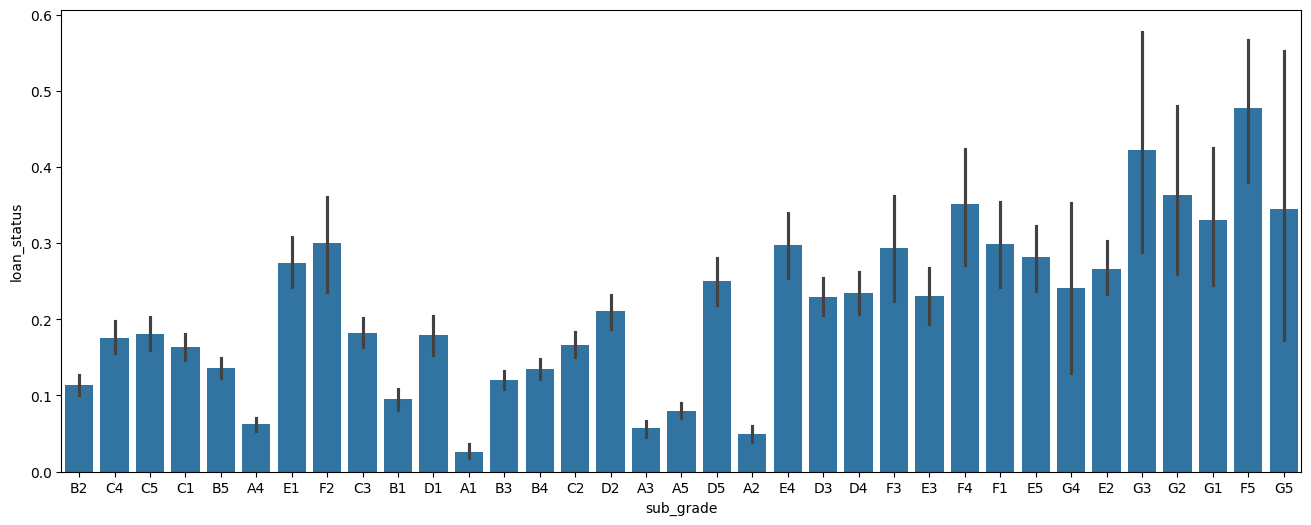

In [ ]:
plt.figure(figsize=(16,6))
plot_cat('sub_grade')

*Sub Grade Chart*

Here we can the A1 and A2 grade has the lowest risk compared to g range grades.

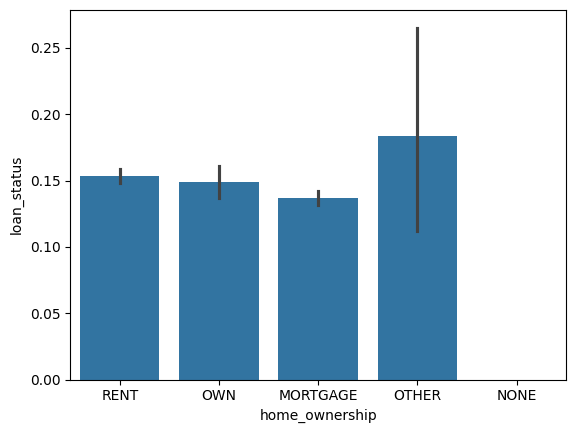

In [ ]:
plot_cat('home_ownership')

*Home Ownership Chart*

As we can see we cannot easily target the ownership number for defaulters.


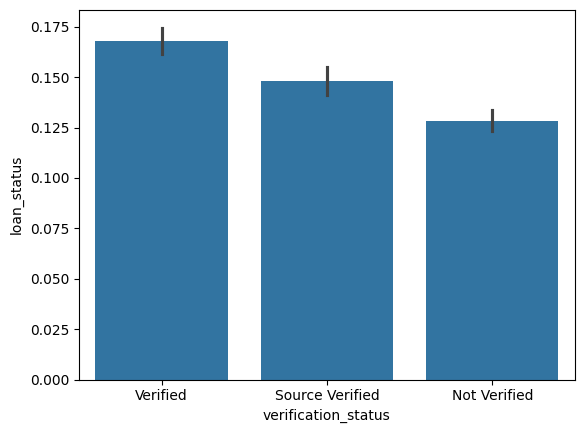

In [ ]:
plot_cat('verification_status')

*Verification Status Chart*

As we can see that verfied has more defaulters then compared to others. That's why there is need to focus on verification status

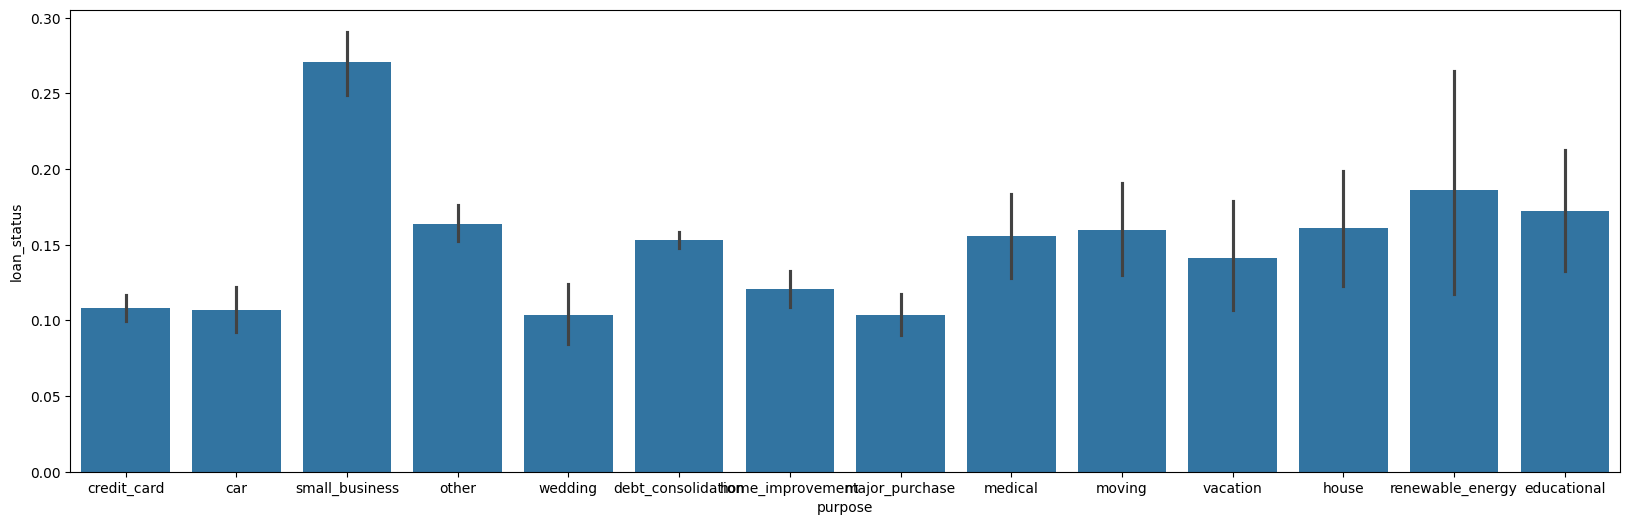

In [ ]:
plt.figure(figsize=(20,6))
plot_cat('purpose')

*Purpose* *Chart*

In the purpose chart, small business, moving and medical are some purposes where the defaulters rate are high compared to others.

In [ ]:
df['issue_d'].head(10)

In [ ]:
#conerting the datetime for analysis
df['issue_d']=pd.to_datetime(df['issue_d'],format='%b-%y')

In [ ]:
#extracting the month and year
df['month']=df['issue_d'].dt.month
df['year']=df['issue_d'].dt.year

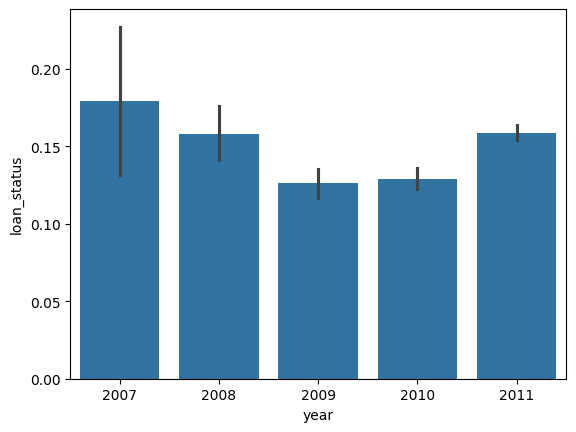

In [ ]:
plot_cat('year')

*Year Chart *

as we can noticed the loan defaulters has been decreased after 2007 and a small proportion of increase is still noticed in 2011.

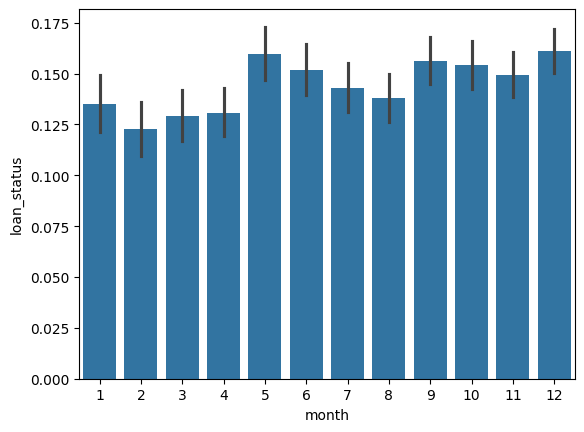

In [ ]:
plot_cat('month')

*Month Chart*

here the starting of month as equal defualters but after apirl there is increase in defaulters rate.

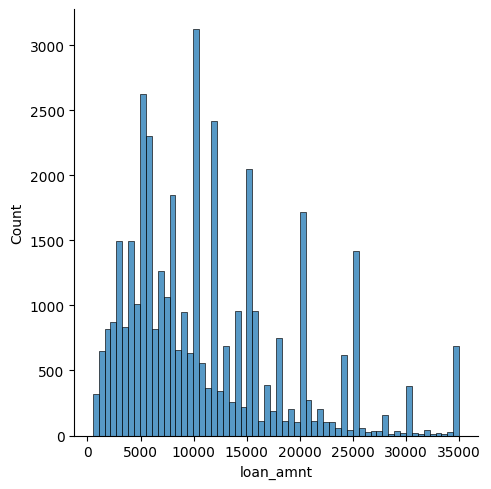

In [ ]:
sns.displot(df['loan_amnt'])
plt.show()

We have to futher catergorized the amounts to easily analyse.

In [ ]:
def loan_amnt(n):
  if n < 5000:
     return 'low'
  elif n > 5000 and n < 15000:
    return 'moderate'
  elif n >= 15000 and n <= 25000:
    return 'high'
  else:
    return 'very high'

df['loan_amnt']=df['loan_amnt'].apply(lambda X:loan_amnt(X))


In [ ]:
 df['loan_amnt'].value_counts()

,count
loan_amnt,
moderate,19051
high,9485
low,7517
very high,3664


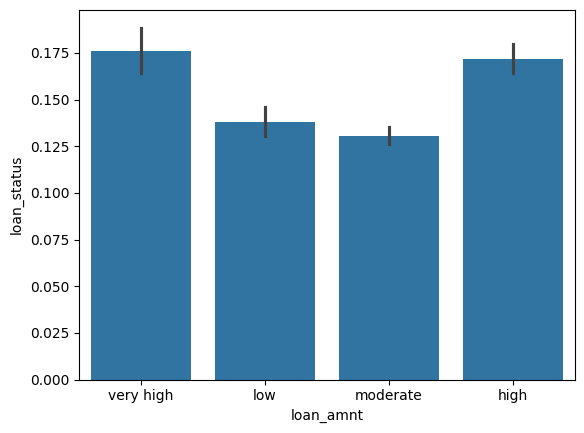

In [ ]:
plot_cat('loan_amnt')

*Loan Amount Chart*

The Loan Amount which is higher the default rate is also higher.
Hence, it can be a noticble point.

In [ ]:
#converting loan amnt inv into bins.
df['funded_amnt_inv']=df['funded_amnt_inv'].apply(lambda X:loan_amnt(X))

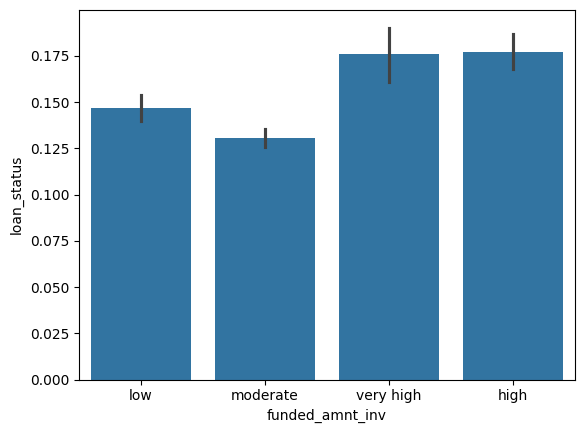

In [ ]:
plot_cat('funded_amnt_inv')

*Loan Amount Funded Chart*

As same as loan amount the higher the amount,higher the risk of defaulters.
Hence it is important point.

In [ ]:
def int_rate(n):
  if n <=10:
    return 'low'
  elif n > 10 and n <=15:
    return 'moderate'
  else:
    return 'high'

df['int_rate']=df['int_rate'].apply(lambda X:int_rate(X))

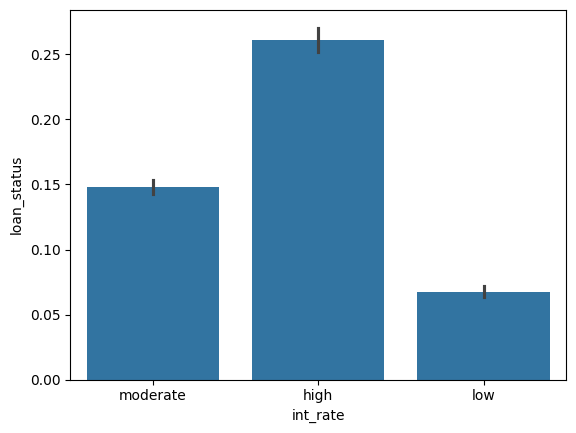

In [ ]:
plot_cat('int_rate')

*Interest Amount Chart*

Here the most important the interest rates on those loans which is higher than 15% the defaulters are very high compared to the interest rates, this is very common reason for deafaulters in the loans.

In [ ]:
#debt to income ratio
def dti(n):
  if n <= 10:
    return 'low'
  elif n > 10 and n <=20:
    return 'moderate'
  else:
    return 'high'

df['dti']=df['dti'].apply(lambda x:dti(x))

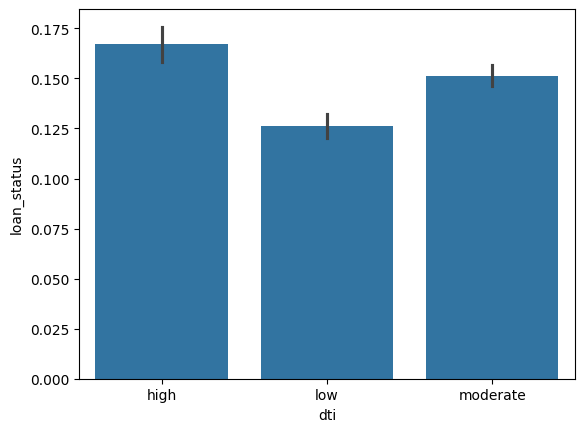

In [ ]:
plot_cat('dti')

*Debt to Income Ratio*

A debt-to-income (DTI) ratio is a personal finance metric comparing monthly debt payments to gross monthly income, expressed as a percentage

as seen before high dti means high deafaulters risk




In [ ]:
#funded amount category wise bin creation
def funded_amount(n):
  if n <= 5000:
    return 'low'
  elif n > 5000 and n<= 15000:
    return 'medium'
  else:
    return 'high'

df['funded_amnt']=df['funded_amnt'].apply(lambda x:funded_amount(x))


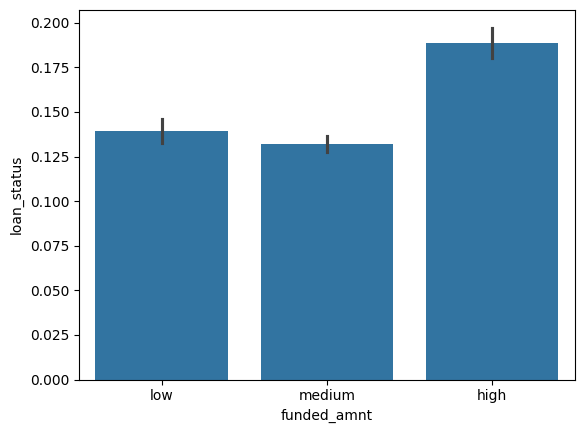

In [ ]:
plot_cat('funded_amnt')

***Funded Amount Chart***

Here in the chart we can analyse the similar thing which is higher the amount of funded amount the higher the risky factor.

In [ ]:
#installments

def installment(n):
  if n < 200:
    return 'low'
  elif n >= 200 and n <=400:
    return 'moderate'
  else:
    return 'high'

df['installment']=df['installment'].apply(lambda x:installment(x))

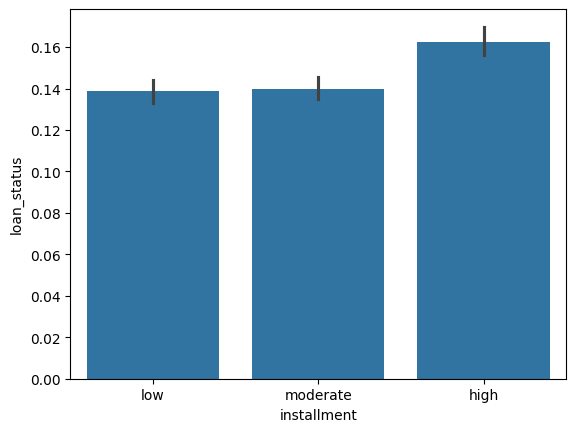

In [ ]:
plot_cat('installment')

***Installment Chart ***

Installment Chart shows that high installment leads to high risk of default risks which are greater that 600 and hence the larger amount leads to larger proportion of defaulters.

In [ ]:
#dividing annual income into four categories

def annual_income(n):
  if n<= 50000:
    return 'low'
  elif n > 50000 and n <=100000:
    return 'medium'
  elif n > 100000 and n <= 150000:
    return 'high'
  else:
    return 'very high'

df['annual_inc']=df['annual_inc'].apply(lambda x:annual_income(x))

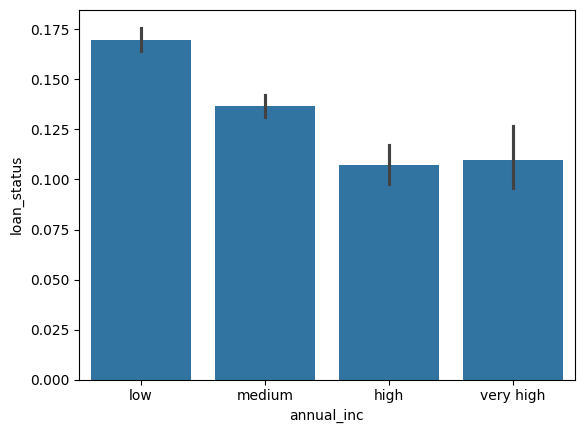

In [ ]:
plot_cat('annual_inc')

*Annual Income Chart*


In this chart, the people with lower income of 50000 are the most proportion of defaulters as it is difficult for a common man to pay debts with such income amount.
Hence, a criteria should be set up for lower income people such as limited amount of borrowings, low interest rates and financial securities.

In [ ]:
#first step is to drop null value columns
df = df[~df['emp_length'].isnull()]


In [ ]:
#dividing employe length into four category such as fresher, junior, senior and expert
def emp_length(n):
  if n<=1 :
    return 'fresher'
  elif n> 1 and n<3:
    return 'junior'
  elif n> 3 and n<=7:
    return 'senior'
  else:
    return 'expert'

df['emp_length']=df['emp_length'].apply(lambda x:emp_length(x))

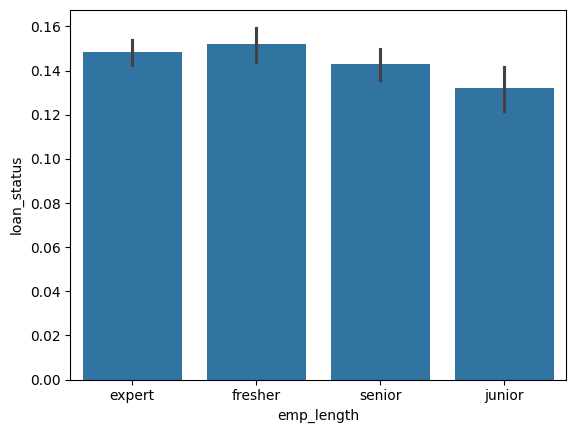

In [ ]:
plot_cat('emp_length')

*Employee Length Chart*

Here we first divided the employee working years in their current company into four bins and as we can see the deafault rates among each category is equal and also highest among them are the ones who are freshers.

# ***Univariate Analysis***


Here, we considered the main variables such amount funded, interest rates, installment amount, purpose of loan in defaulters rates.

With the help of visiuals we can notice a similar thing which the higher the amount of amount funded, interest rates, installment etc leads to higher the deafualters proportion.

Even the verfied loans were having the larger number of defaulters.

People with lower income and low number of years experience were also the high number of defaulters.

Here we have analysed by comparing different elemnts with loan status without counting the current active status account.

# ***Segemnted Univariate Analysis***


Segemented Univariate Analysis means analyze one variable across different groups.

Such as in this case we would analysing the purpose of the credit with targeted variable as in credit industry it is important to take the purposes as targeted variable

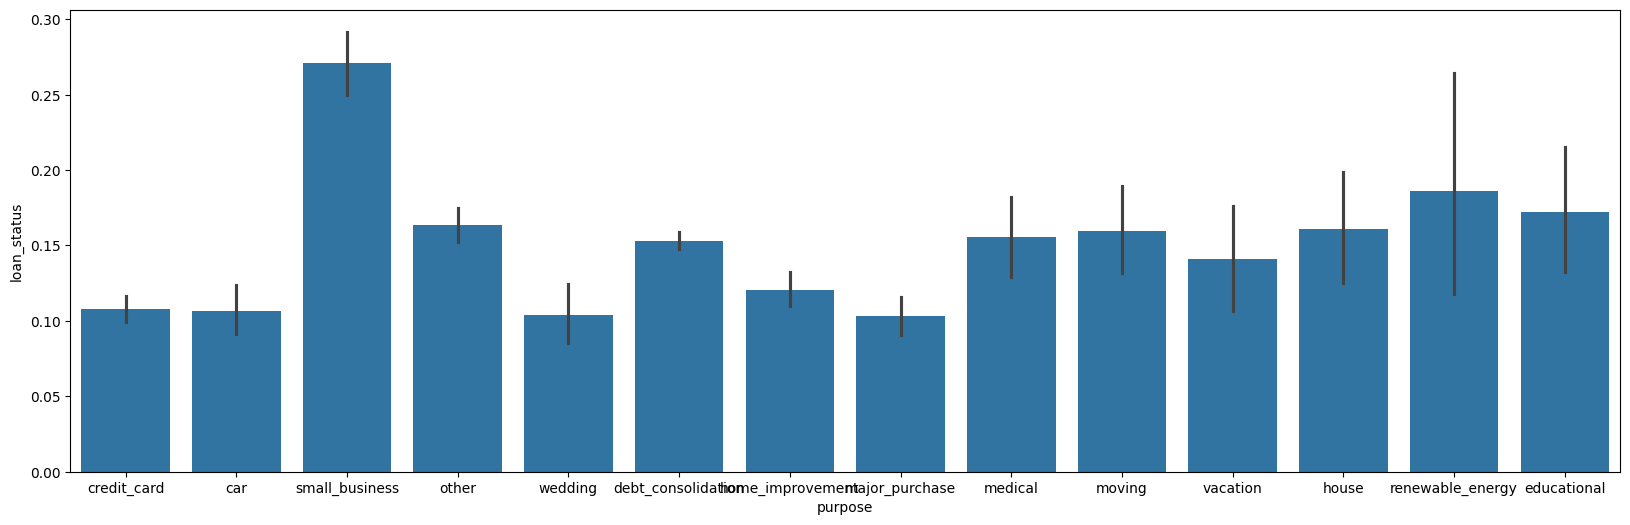

In [ ]:
plt.figure(figsize=(20,6))
plot_cat('purpose')

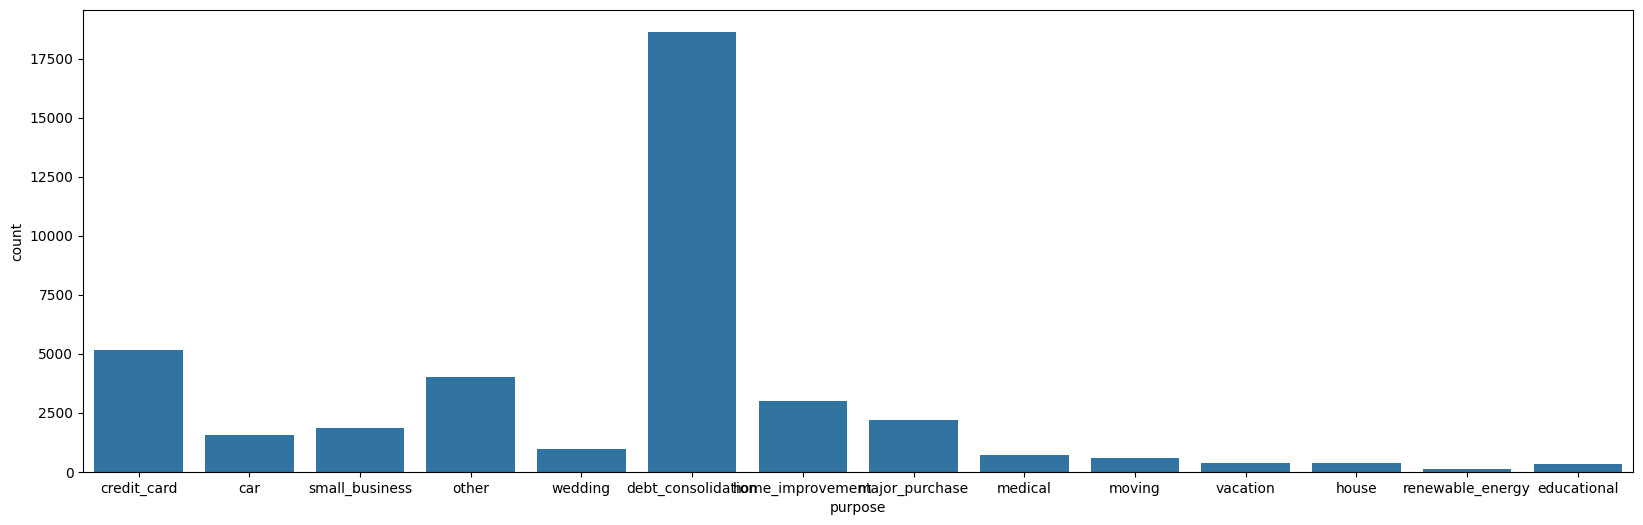

In [ ]:
#let's analyse with numbers of each columns
plt.figure(figsize=(20,6))
sns.countplot(x='purpose',data=df)
plt.show()

Here, most of the common purpose of taking loan is to repay other loans.
we would analysing in detail with debt consolidation,credit_card, home improvement and major purchase.

In [ ]:
#filtering the data frame into four elements.
main_purpose=['credit_card','debt_consolidation','home_improvement','major_purchase']
df=df[df['purpose'].isin(main_purpose)]
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,18641
credit_card,5130
home_improvement,2976
major_purchase,2187


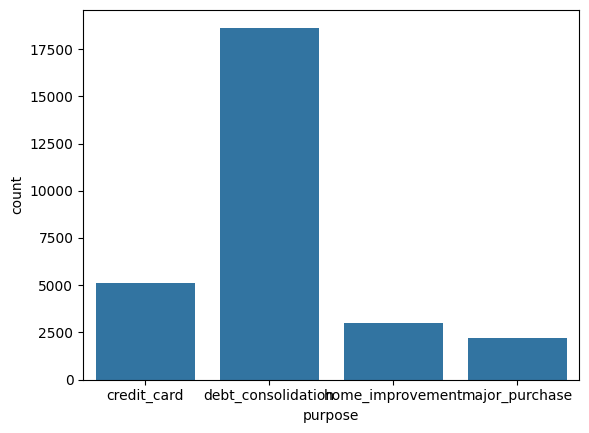

In [ ]:
#plotting numbers into countplot
sns.countplot(x=df['purpose'])
plt.show()

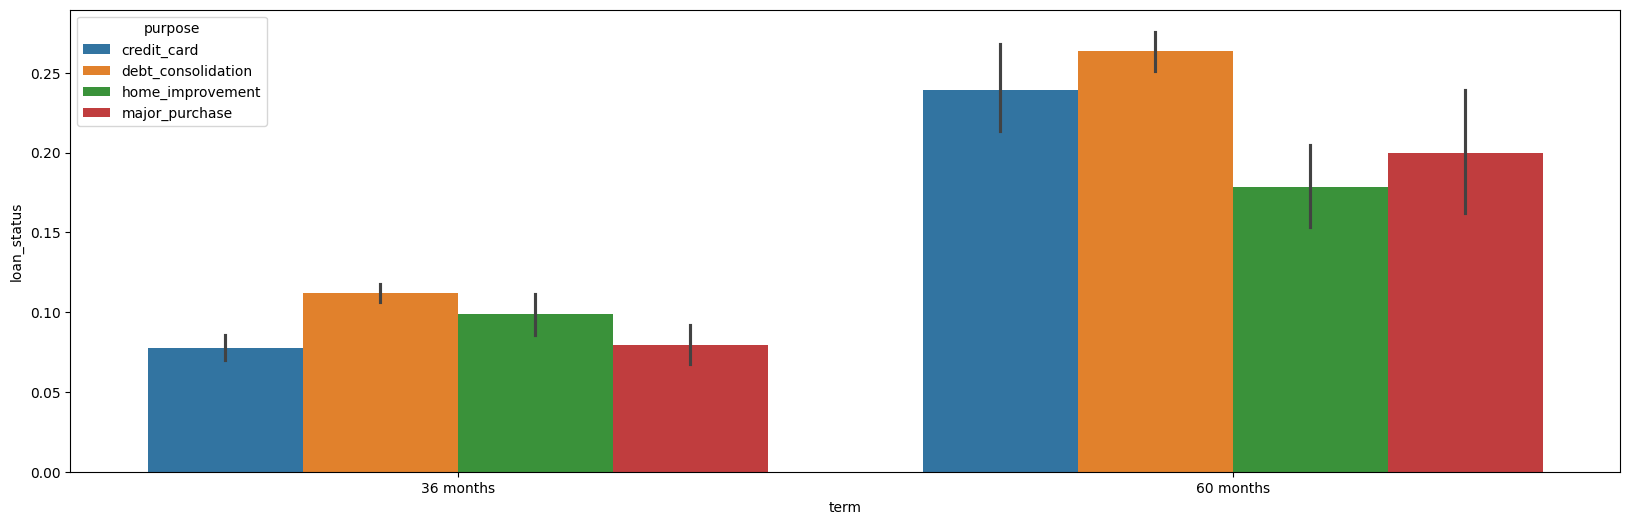

In [ ]:
#comparing the default variable with two types of categories

plt.figure(figsize=(20,6))
sns.barplot(x='term',y='loan_status',data=df,hue='purpose')
plt.show()

In this chart, in long term loans every variable is high such as purpose.
it means the term also makes a major affect with purpose.



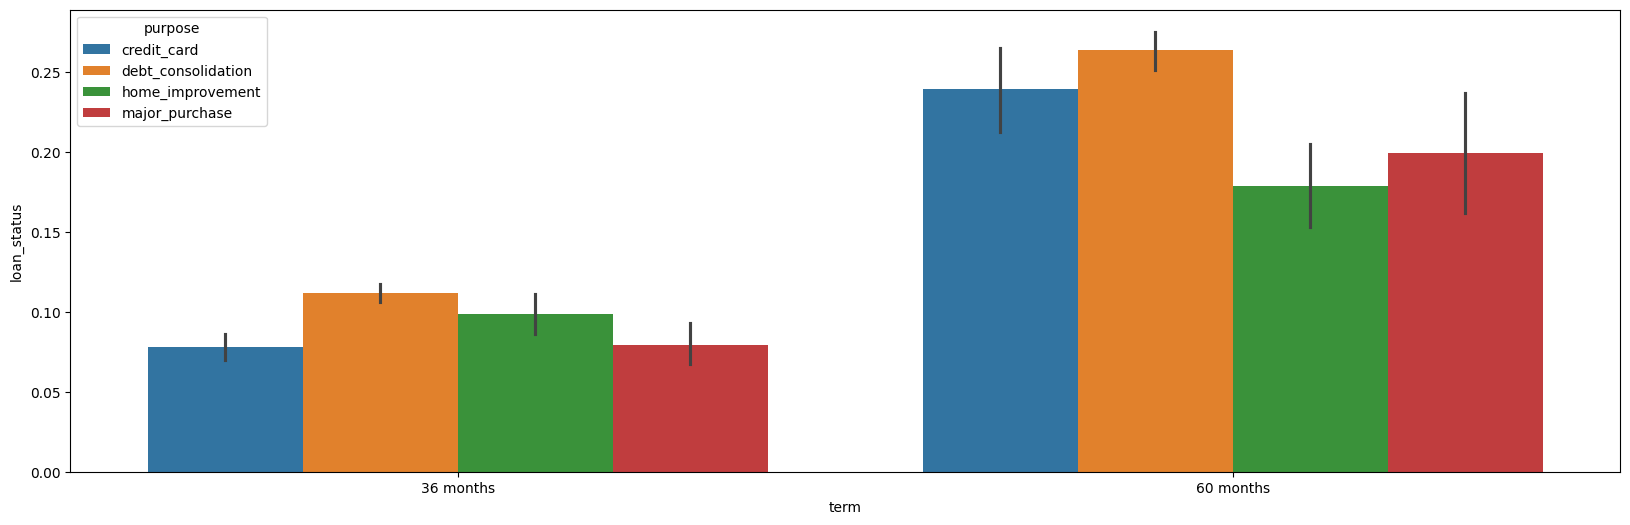

In [ ]:
#preparing a function which prepares a catergorial variable and plots the default rates

def plot_segemnt(cat_var):
  plt.figure(figsize=(20,6))
  sns.barplot(x=cat_var,y='loan_status',data=df,hue='purpose')
  plt.show()

plot_segemnt('term')

# ***Term and Purpose Chart:***


Here as we can notice that there is a large differnce between 36 months and 60 months.
All the Four purposes such as credit card, debt consolidation, home improvement and major purchase defaulters have increased in long term loans.

But in both the term the debt consolidation defaulters percentage is highest.
In 36 months, credit card defaulters was lowest and in next term the home imporvement is lowest among other four purposes.

If we take a percentage of increase of dafault rate in both the terms it is 127%
which is to be taken noticed.


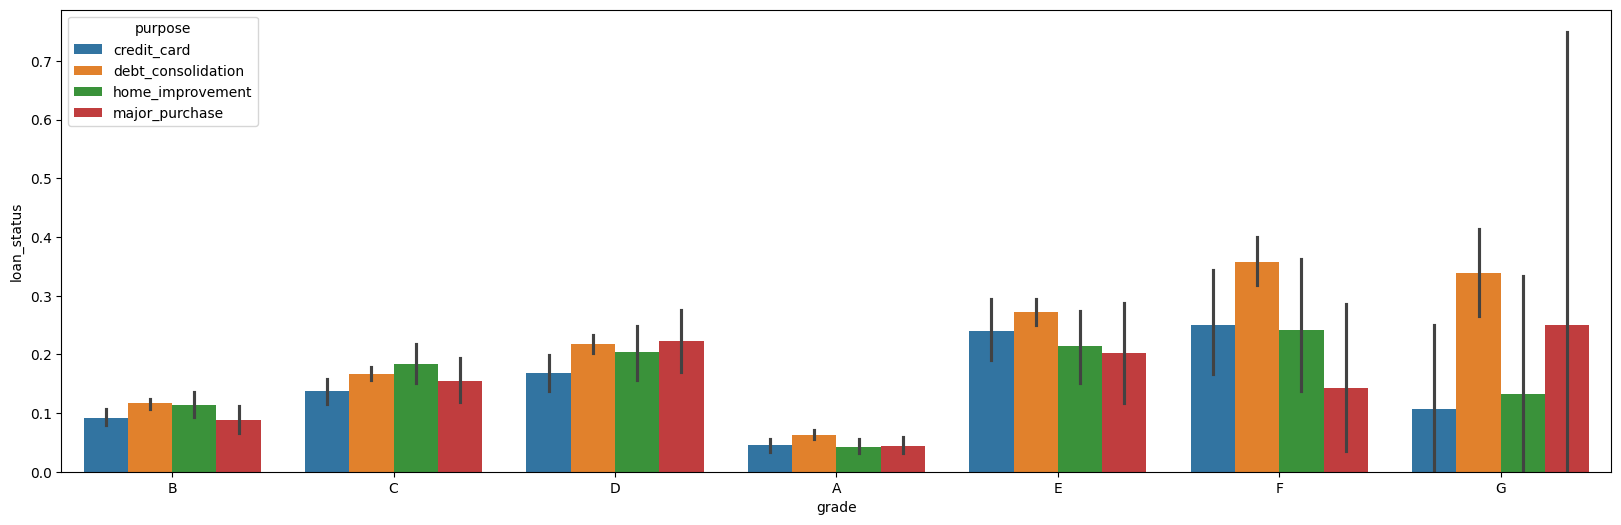

In [ ]:
plot_segemnt('grade')

# ***Grade and Purpose Chart***


Here the grade is given where A grade is the safest loan and G is risky grade.

As we can see the defaulters rate keeps increasing from A and G among all the four purposes.

Debt Consolidation has highest number of defaulters in all the grades and as incresed from 0.05 in grade A to 0.3 in grade G.

Credit card  and home improvement defaulters rate decrease from grade e to grade g.

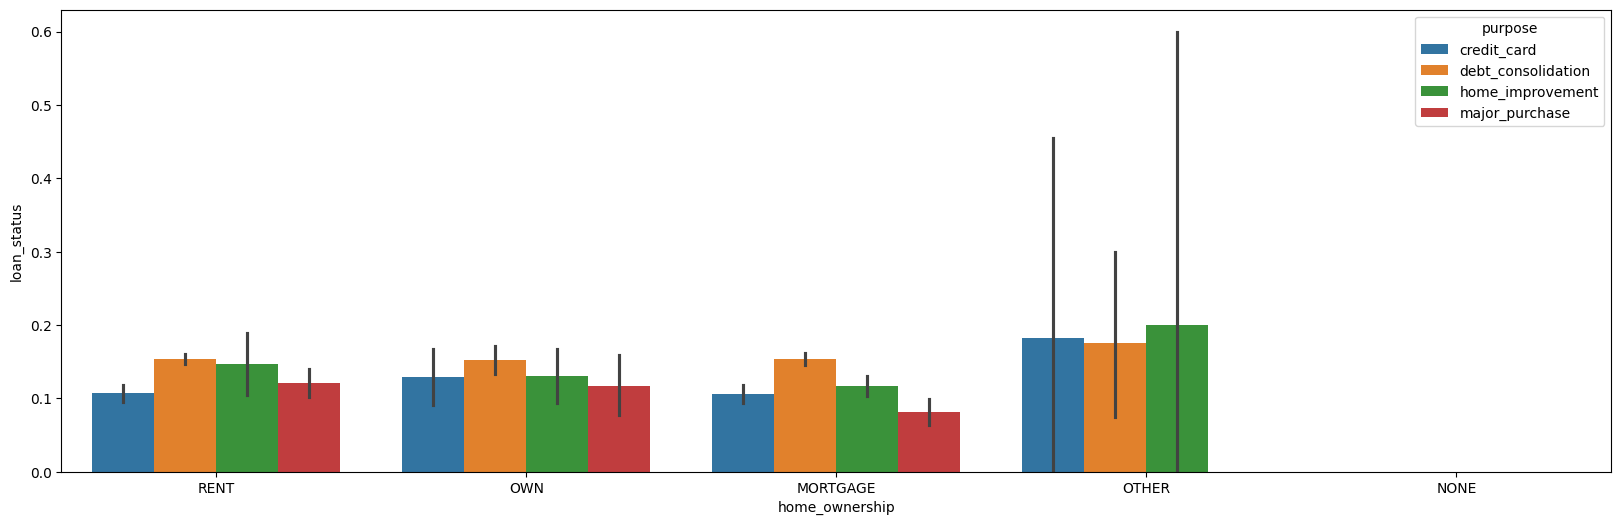

In [ ]:
plot_segemnt('home_ownership')

# ***Home Ownership and Purpose Chart***


Here, in this Chart there is not a major differnece between the home ownership. Defaulters from debt consolidation is still on the highest amnong other three purposes.
In Mortage the default rate of major purchase has decreased compared to owner and rented.

While where the home ownership is not difined as the highest number of defaulters rate in credit card, debt consolidation and mortgage.

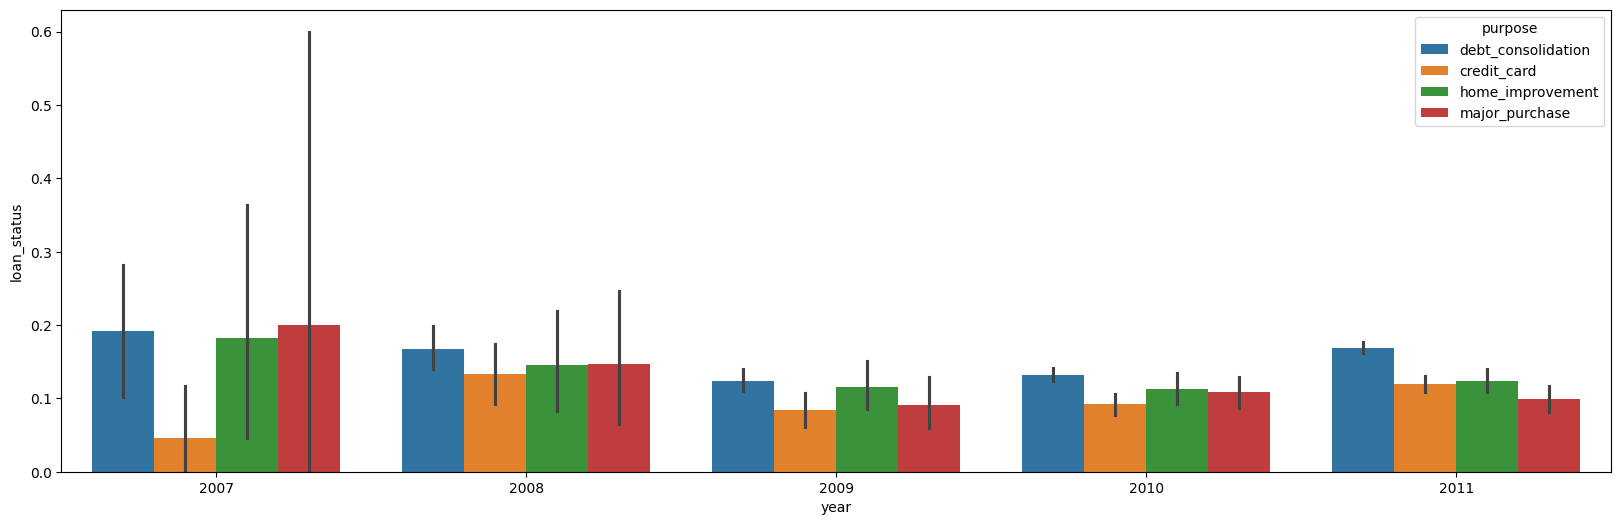

In [ ]:
plot_segemnt('year')

# ***Year and Purpose Chart:***

In 2007, the defaulters rate among all the four courses are highest compared to the default rate in 2011.

In 2011 there is a increase in all the four purposes default rates from 2010.
Credit Card has the highest default rates in all the years.

There must be some changes in credit card policy.

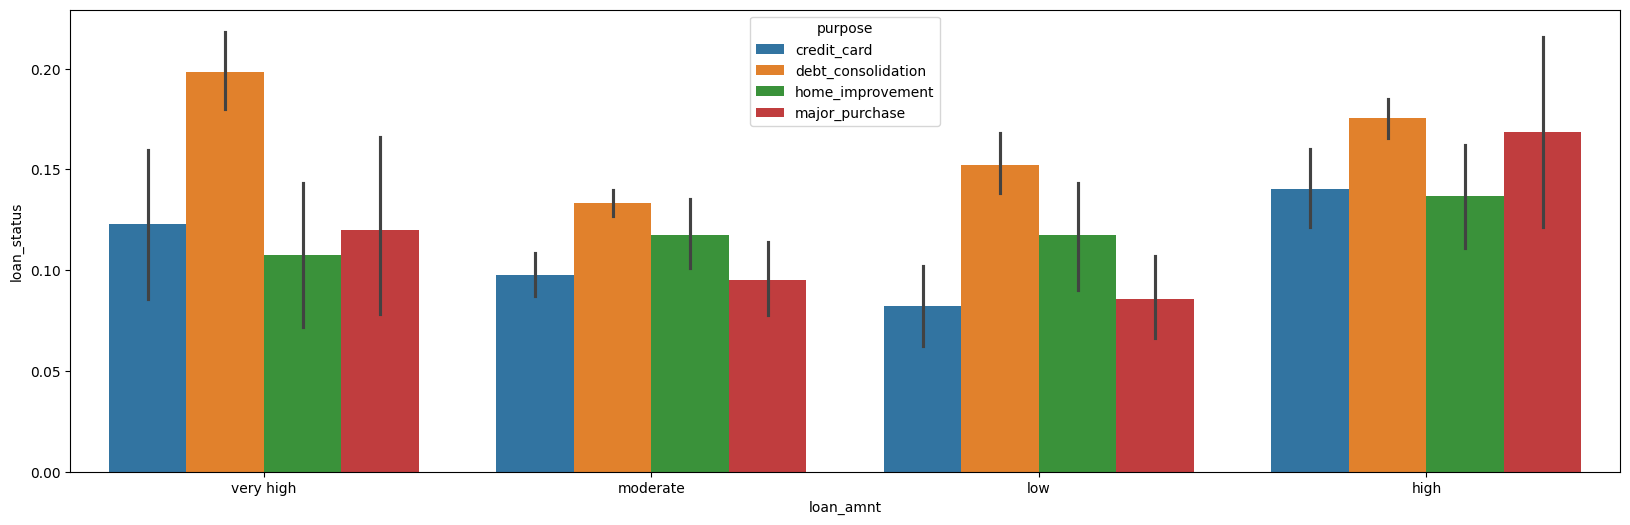

In [ ]:
plot_segemnt('loan_amnt')

# ***Loan Amount and Purpose Chart***

The loan amount is divided into four categories which is low, moderate, high and very high.

As in early charts we have notice a important point which is higher the amount leads to higher in defaulters rate.
Here also we can see that in very high all the purposes have highest number of default rates among them.




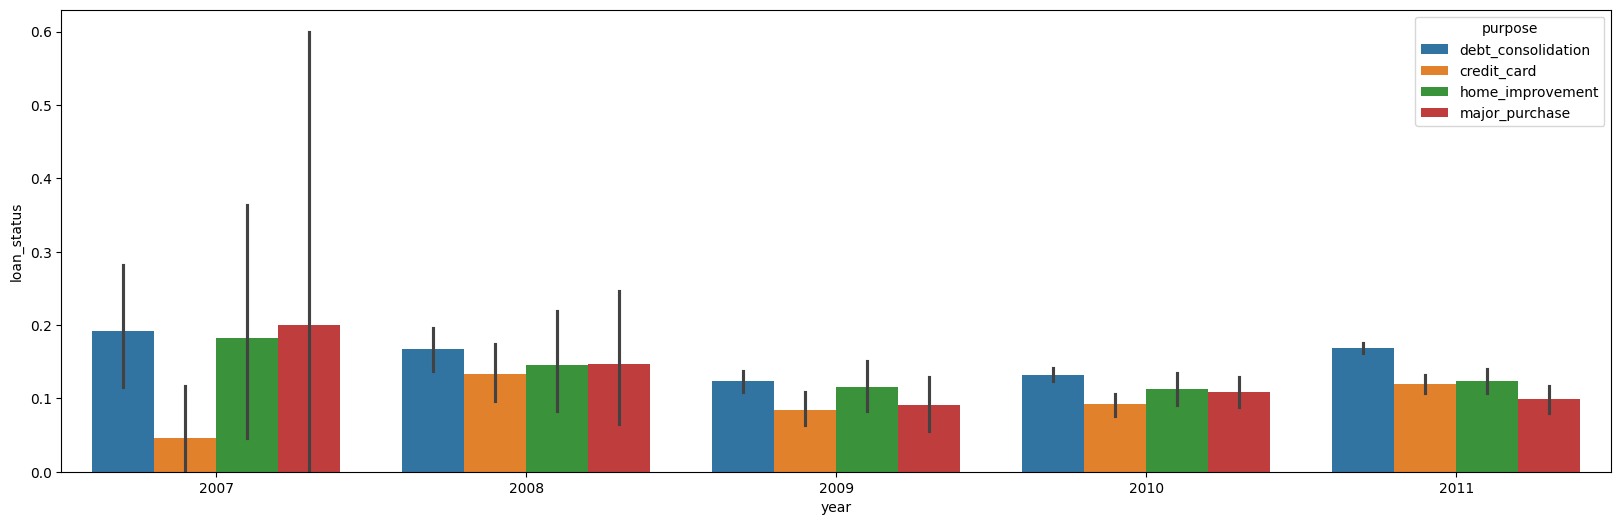

In [ ]:
plot_segemnt('year')

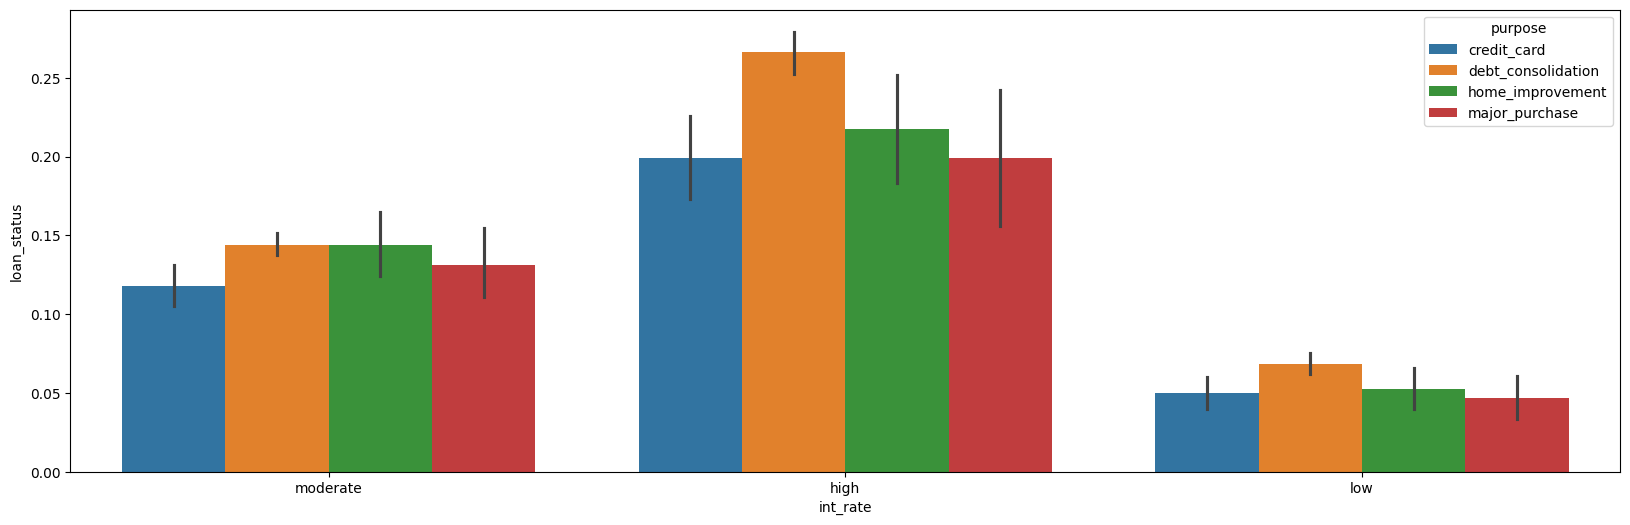

In [ ]:
plot_segemnt('int_rate')

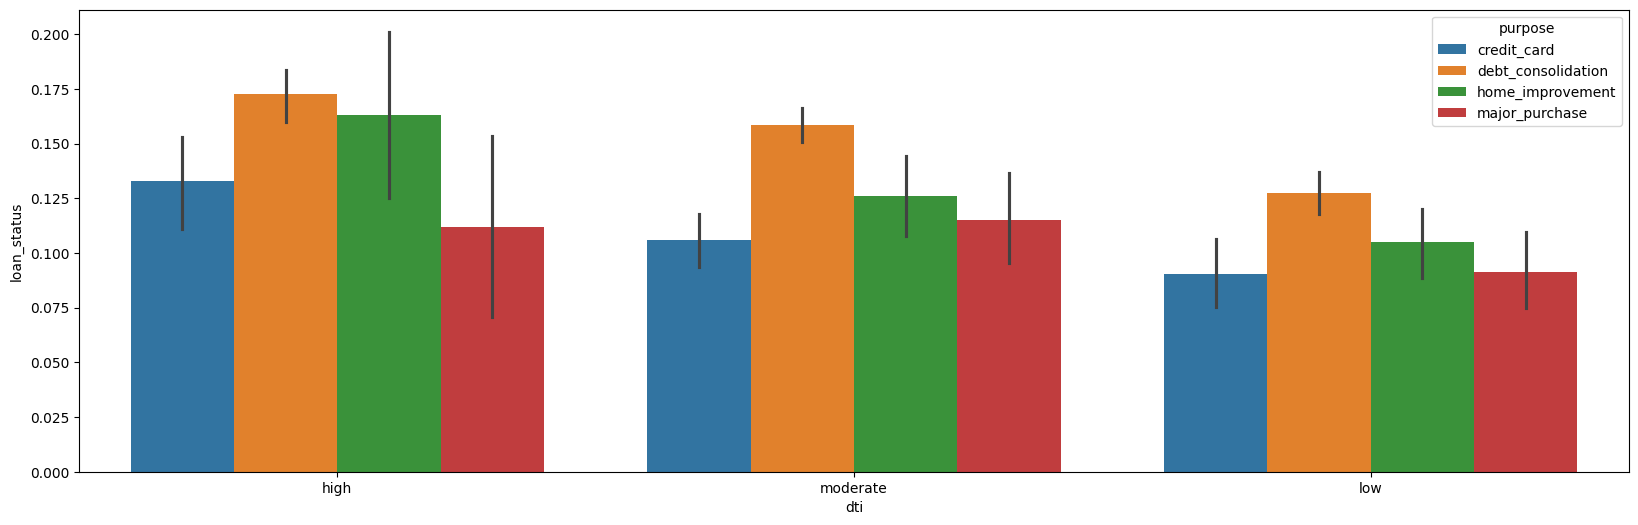

In [ ]:
plot_segemnt('dti')

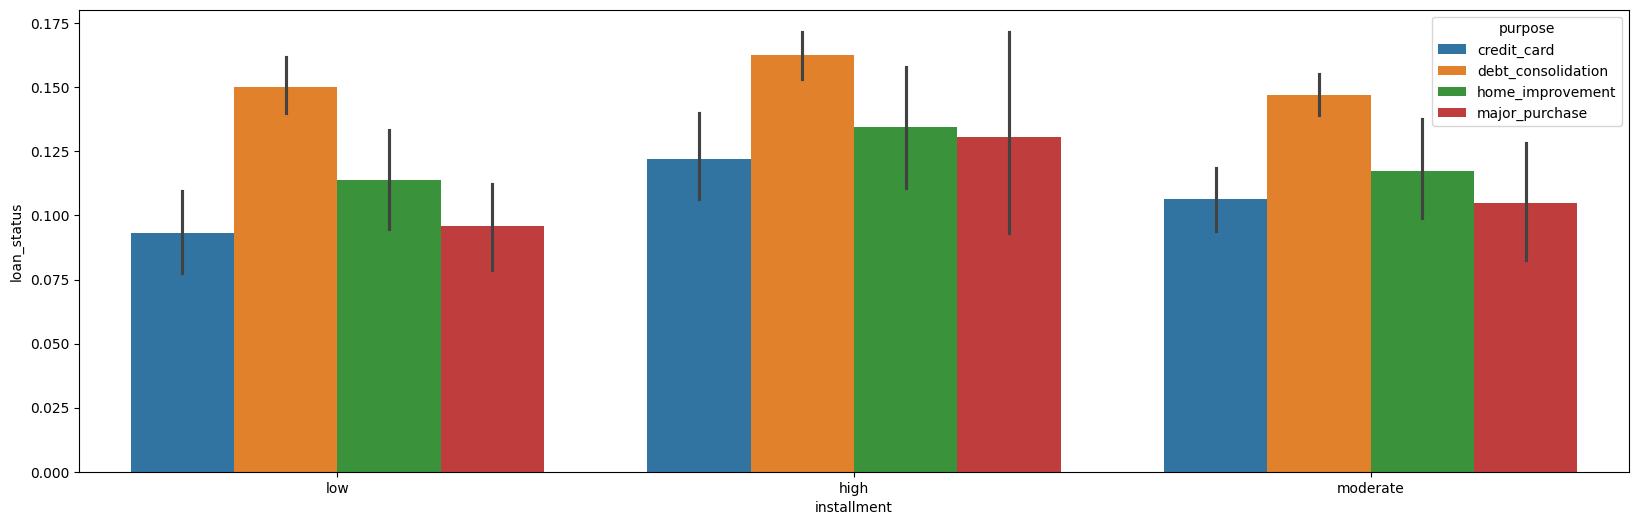

In [ ]:
plot_segemnt('installment')

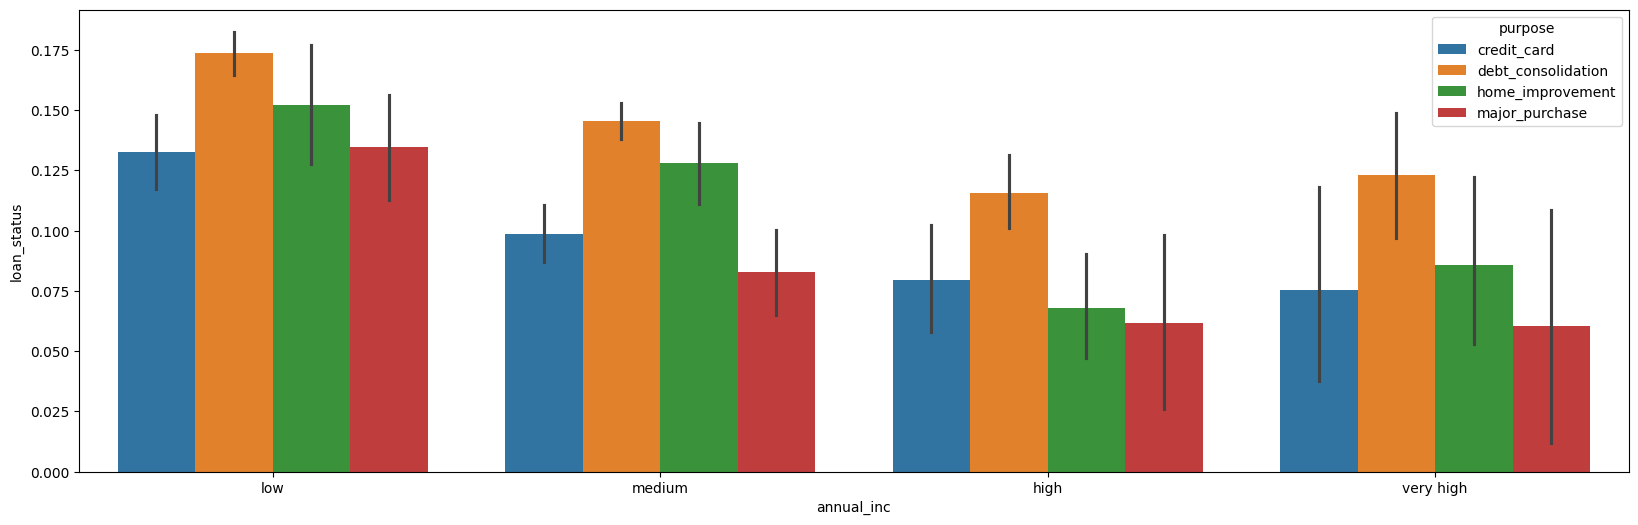

In [ ]:
plot_segemnt('annual_inc')